# اجرای نهایی پژوهش پایان‌نامه در Google Colab
**هدف:** اجرای یکپارچه و End-to-End خط لوله پردازش تصاویر پزشکی، استخراج ROI با شبکه U-Net، و اعمال رمزنگاری ابرآشوبی ۵ بعدی و پنهان‌نگاری.
این نوت‌بوک از کدهای تست و دیباگ پاک‌سازی شده و مستقیماً برای تولید نتایج، مانیفست‌ها، وزن‌های مدل و گزارش‌های آماری (CSV/JSON/NIST) استفاده می‌شود.

In [ ]:
# [گام ۱]: نصب کتابخانه‌های مورد نیاز
%pip install -q --upgrade kagglehub


In [ ]:
# [گام ۲]: آپلود فایل زیپ کدها (medsec_colab.zip) و استخراج آن
from pathlib import Path
import os, sys, zipfile
from google.colab import files

print("لطفاً فایل medsec_colab.zip نهایی را انتخاب کنید:")
uploaded = files.upload()
archives = [Path(name) for name in uploaded if name.endswith('.zip')]

if len(archives) != 1:
    raise ValueError('دقیقاً یک فایل ZIP باید انتخاب شود.')

ROOT = Path('/content/thesis_toolkit')
ROOT.mkdir(exist_ok=True)

with zipfile.ZipFile(archives[0]) as z:
    for name in z.namelist():
        if not (ROOT/name).resolve().is_relative_to(ROOT.resolve()):
            raise ValueError('Unsafe zip')
    z.extractall(ROOT)

PACKAGE = ROOT / 'medsec_colab'
os.chdir(PACKAGE)
sys.path.insert(0, str(PACKAGE))

print('\\nمسیر بسته کدهای پایان‌نامه:', PACKAGE)

لطفاً فایل medsec_colab.zip نهایی را انتخاب کنید:


Saving medsec_colab.zip to medsec_colab.zip
\nمسیر بسته کدهای پایان‌نامه: /content/thesis_toolkit/medsec_colab


In [ ]:
from scripts.normalization import load_sample_normalized, extract_patient_stem
from scripts.data import USE_MIXED, MIXEDDataset
print("کتابخانه‌های پیش‌نیاز با موفقیت نصب شدند.")

کتابخانه‌های پیش‌نیاز با موفقیت نصب شدند.


In [ ]:
# [گام ۳]: اتصال به گوگل درایو و پیکربندی متغیرهای اساسی خط لوله
import os
from pathlib import Path
import torch

# اتصال به گوگل درایو برای ذخیره ماندگار وزن‌ها و نتایج
MOUNT_DRIVE = True
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

os.environ['THESIS_WORKDIR'] = '/content/drive/MyDrive/Thesis_Research' if MOUNT_DRIVE else '/content/Thesis_Research'
WORK = Path(os.environ['THESIS_WORKDIR'])
WORK.mkdir(parents=True, exist_ok=True)

# ----------------- تنظیمات اجرایی -----------------
DATASET = 'CHASE_STARE_Merged'  # انتخاب دیتاست فعلی (پشتیبانی از: DRIVE, CHASE_DB1, STARE, FIVES)
USE_MIXED = True  # پرچم فعال‌سازیPipeline ادغام شده با نرمال‌سازی جهانی
EPOCHS = 40        # تعداد ایپاک‌های آموزش U-Net (حداقل 40 برای همگرایی استاندارد)

# پرچم‌های کنترلی (فعال بودن مراحل اصلی)
RUN_TRAINING = True
RESUME_TRAINING = False
RUN_EXPERIMENTS = True
RUN_NIST = True

# ----------------- مسیردهی فایل‌ها -----------------
DATA_ROOT = WORK / 'data_sources' / DATASET
MANIFEST = WORK / f'{DATASET}_manifest.jsonl'
WEIGHTS = WORK / 'weights' / DATASET
PAYLOAD = WORK / 'metadata.bin'
RUN_DIR = WORK / 'runs' / f'{DATASET}_final_results'
PROFILE = Path('/content/thesis_toolkit/medsec_colab/scripts/thesis_reference.json')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print("="*50)
print(f"✅ دستگاه پردازشی: {DEVICE.upper()}")
print(f"✅ پوشه اصلی کار: {WORK}")
print(f"✅ دیتاست هدف: {DATASET}")
print(f"✅ آموزش مدل: {'فعال' if RUN_TRAINING else 'غیرفعال'} ({EPOCHS} Epochs)")
print(f"✅ ارزیابی و رمزنگاری: {'فعال' if RUN_EXPERIMENTS else 'غیرفعال'}")
print("="*50)

In [ ]:
# [گام ۴]: دانلود و استخراج یکپارچه مجموعه‌داده‌های پزشکی
import os, hashlib, shutil, zipfile, tempfile
from pathlib import Path
from urllib.request import Request, urlopen
import kagglehub

# 📌 لیست دیتاست‌هایی که می‌خواهید در سیستم (گوگل درایو) موجود باشند.
# می‌توانید هر کدام را که فعلاً نیاز ندارید از لیست حذف کنید.
TARGET_DATASETS = ['DRIVE','CHASE_DB1', 'STARE']

print(f"در حال بررسی و دریافت دیتاست‌ها: {TARGET_DATASETS}\n" + "="*50)

def file_hash(path):
    h = hashlib.sha256()
    with Path(path).open('rb') as f:
        for block in iter(lambda: f.read(1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

# --- ۱. مدیریت دیتاست DRIVE (نسخه کاگل سفارشی با بررسی هش) ---
if 'DRIVE' in TARGET_DATASETS:
    drive_src = WORK / 'data_sources' / 'DRIVE'
    drive_zip = WORK / 'downloads' / 'DRIVE-kaggle-v1.zip'
    EXPECTED_SHA256 = '3efa1bf264da71a9080c9959c5ee89e2646193892efe9d66f29a4123b74f949a'
    URL = 'https://www.kaggle.com/api/v1/datasets/download/andrewmvd/drive-digital-retinal-images-for-vessel-extraction?datasetVersionNumber=1'

    if drive_src.is_dir() and (drive_src / 'training').exists():
        print("✅ دیتاست DRIVE: از قبل موجود است.")
    else:
        print("⏳ دیتاست DRIVE: در حال دانلود...")
        drive_zip.parent.mkdir(parents=True, exist_ok=True)
        if not drive_zip.exists() or file_hash(drive_zip) != EXPECTED_SHA256:
            req = Request(URL, headers={'User-Agent': 'ThesisResearch/1.0'})
            with urlopen(req, timeout=90) as resp, drive_zip.open('wb') as f:
                shutil.copyfileobj(resp, f)

        if file_hash(drive_zip) == EXPECTED_SHA256:
            with tempfile.TemporaryDirectory(dir=drive_src.parent) as tmp:
                with zipfile.ZipFile(drive_zip) as z:
                    z.extractall(tmp)
                (Path(tmp) / 'DRIVE').rename(drive_src)
            print("✅ دیتاست DRIVE: با موفقیت استخراج شد.")
        else:
            print("❌ دیتاست DRIVE: خطای عدم تطابق هش!")

# --- ۲. مدیریت سایر دیتاست‌ها با Kagglehub ---
cache_root = WORK / "data_sources" / "_kaggle_cache"
os.environ["KAGGLEHUB_CACHE"] = str(cache_root)
os.environ["DISABLE_COLAB_CACHE"] = "true"

catalog = {
    "CHASE_DB1": "namnguynnnn/chase-db1/versions/1",
    "STARE": "aryankamani/stare-dataset-20images/versions/1",
    "FIVES": "nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation/versions/6",
}

for ds_name in ["CHASE_STARE_Merged"]:
    if ds_name in catalog:
        handle = catalog[ds_name]
        ds_root = cache_root / handle
        # بررسی اینکه آیا پوشه وجود دارد و خالی نیست
        if ds_root.is_dir() and any(ds_root.rglob('*')):
            print(f"✅ دیتاست {ds_name}: از قبل در کش موجود است.")
        else:
            print(f"⏳ دیتاست {ds_name}: در حال دانلود از Kaggle...")
            dl_path = kagglehub.dataset_download(handle)
            print(f"✅ دیتاست {ds_name}: با موفقیت دریافت شد.")

print("="*50 + "\nآماده‌سازی مجموعه‌داده‌ها به پایان رسید.")

In [ ]:
# [گام ۵]: آماده‌سازی فایل پیام مخفی (Payload)
import numpy as np

if not PAYLOAD.exists():
    print("در حال ساخت فایل پیام (Payload) استاندارد...")
    rng = np.random.default_rng(2026) # Seed ثابت برای تکرارپذیری پایان‌نامه
    # تولید یک فایل 50 کیلوبایتی
    payload_data = rng.integers(0, 256, size=50_000, dtype=np.uint8).tobytes()
    PAYLOAD.write_bytes(payload_data)
    print(f"✅ فایل پیام مخفی ایجاد شد: {PAYLOAD.name}")
else:
    print(f"✅ فایل پیام مخفی از قبل موجود است: {PAYLOAD.name}")

✅ فایل پیام مخفی از قبل موجود است: metadata.bin


In [ ]:
# ===== CELL 7: Manifest Generation =====
import json
import hashlib
import random
from pathlib import Path
from collections import Counter

# [ادغام Imports نرمال‌سازی] - ADDITION
from scripts.normalization import load_sample_normalized, extract_patient_stem

dataset_name = "CHASE_STARE_Merged"
manifest_path = Path(WORK) / f"{dataset_name}.jsonl"
cache_base = Path(WORK) / "data_sources/_kaggle_cache/datasets"

# مسیرهای استخراج‌شده توسط Kagglehub
chase_root = cache_base / "namnguynnnn/chase-db1/versions/1"
stare_root = cache_base / "aryankamani/stare-dataset-20images/versions/1"

def get_sha256(filepath):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(1024*1024), b""):
            h.update(chunk)
    return h.hexdigest()

print(f"در حال ایجاد مانیفست یکپارچه برای {dataset_name}...")
records = []
random.seed(2026)

# 1. افزودن نمونه‌های CHASE_DB1 (کل 28 تصویر)
if chase_root.is_dir():
    chase_imgs = sorted(list(chase_root.glob("*.jpg")))
    if not chase_imgs: chase_imgs = sorted(list(chase_root.rglob("Image_*.jpg")))

    for idx, img_path in enumerate(chase_imgs):
        patient_stem = extract_patient_stem(img_path.name)
        mask_candidates = list(chase_root.rglob(f"{patient_stem}_1stHO.png"))
        if not mask_candidates: mask_candidates = list(chase_root.rglob(f"{patient_stem}*.png"))
        if not mask_candidates: continue
        mask_path = mask_candidates[0]

        img_hash = get_sha256(img_path)
        # Split logic: last 2 -> test, every 10th -> val, rest -> train
        if idx >= len(chase_imgs) - 2:
            split = "test"
        elif idx % 10 == 0:
            split = "val"
        else:
            split = "train"

        sample = load_sample_normalized(
            image_path=img_path,
            mask_path=mask_path,
            fov_dir=None,
            target_size=(512, 512)
        )

        records.append({
            "id": f"chase_{patient_stem}",
            "dataset": dataset_name,
            "patient_id": f"chase_{patient_stem}",
            "group_id": f"retina:chase_{patient_stem}",
            "split": split,
            "image": str(img_path.resolve()),
            "mask": str(mask_path.resolve()),
            "source": "Kaggle_CHASE_DB1",
            "mask_definition": "first-observer vessels",
            "image_sha256": img_hash,
            "mask_sha256": get_sha256(mask_path),
            "original_shape": sample["original_shape"],
            "resized_shape": sample["resized_shape"],
        })

# 2. افزودن نمونه‌های STARE (کل 20 تصویر)
if stare_root.is_dir():
    stare_imgs = sorted(list(stare_root.rglob("*.ppm")))
    if not stare_imgs: stare_imgs = sorted(list(stare_root.rglob("*.png")))

    for idx, img_path in enumerate(stare_imgs):
        patient_stem = extract_patient_stem(img_path.name)
        mask_candidates = list(stare_root.rglob(f"{patient_stem}.ah.ppm"))
        if not mask_candidates: mask_candidates = list(stare_root.rglob(f"{patient_stem}*.png"))
        if not mask_candidates: continue
        mask_path = mask_candidates[0]

        img_hash = get_sha256(img_path)
        # Split logic: last 2 -> test, every 5th -> val, rest -> train
        if idx >= len(stare_imgs) - 2:
            split = "test"
        elif idx % 5 == 0:
            split = "val"
        else:
            split = "train"

        sample = load_sample_normalized(
            image_path=img_path,
            mask_path=mask_path,
            fov_dir=None,
            target_size=(512, 512)
        )

        records.append({
            "id": f"stare_{patient_stem}",
            "dataset": dataset_name,
            "patient_id": f"stare_{patient_stem}",
            "group_id": f"retina:stare_{patient_stem}",
            "split": split,
            "image": str(img_path.resolve()),
            "mask": str(mask_path.resolve()),
            "source": "Kaggle_STARE",
            "mask_definition": "vessel ground truth",
            "image_sha256": img_hash,
            "mask_sha256": get_sha256(mask_path),
            "original_shape": sample["original_shape"],
            "resized_shape": sample["resized_shape"],
        })

if not records:
    raise ValueError("هیچ تصویری از CHASE_DB1 یا STARE یافت نشد!")

# حذف تکراری‌ها
seen_ids = set()
unique_records = []
for r in records:
    uid = (r["dataset"], r["id"])
    if uid not in seen_ids:
        seen_ids.add(uid)
        unique_records.append(r)
if len(unique_records) < len(records):
    print(f"Removed {len(records)-len(unique_records)} duplicates")
records = unique_records

# تعادل‌دهی تست‌ست (حداقل 10 یا یک‌سوم train)
min_test = max(10, len([r for r in records if r.get("split") == "train"]) // 3)
test_recs = [r for r in records if r.get("split") == "test"]
if len(test_recs) < min_test:
    n_move = min_test - len(test_recs)
    train_recs = [r for r in records if r.get("split") == "train"]
    moved = random.sample(train_recs, n_move)
    for r in moved:
        r["split"] = "test"
    print(f"Balanced test: +{n_move} samples (test now={min_test})")

# نوشتن مانیفست
with manifest_path.open("w", encoding="utf-8") as f:
    for r in records:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

counts = Counter(r["split"] for r in records)
print(f"\n✅ مانیفست ساخته شد ({len(records)} نمونه کل).")
print(f"توزیع داده‌ها: {dict(counts)}")
print(f"📂 مسیر: {manifest_path}")

In [ ]:
# Cell 8: Sanity Check & Pipeline Validation (Phase 1 & 2 Verification)
import scripts
import torch
import numpy as np
from pathlib import Path

# Set USE_MIXED to True for mixed dataset pipeline
scripts.data.USE_MIXED = True

# train_loader را اگر تعریف نشده باشد، بسازم
if 'train_loader' not in locals():
    from torch.utils.data import DataLoader
    from scripts.data import MIXEDDataset
    manifest_path = WORK / "CHASE_STARE_Merged.jsonl"
    if manifest_path.exists():
        mixed_dataset = MIXEDDataset(manifest_path, size=512)
        train_loader = DataLoader(mixed_dataset, batch_size=4, shuffle=True, num_workers=0)
        print("train_loader با MIXEDDataset ایجاد شد")
        print("تعداد کل نمونه‌ها: {}".format(len(mixed_dataset)))
        # نمایش توزیع splitها
        from collections import Counter
        splits = Counter(r.get("split","?") for r in mixed_dataset.records)
        print("توزیع: {}".format(dict(splits)))
    else:
        print("Manifest not found: " + str(manifest_path))

# Extract a batch from the dataloader
sample_batch_images, sample_batch_masks, sample_batch_fov, sample_batch_meta = next(iter(train_loader))
print("Image shape: {}".format(sample_batch_images.shape))
print("Mask shape: {}".format(sample_batch_masks.shape))
print("FOV shape: {}".format(sample_batch_fov.shape))


In [ ]:

# ===== CELL 9: Training =====
from scripts.training import train
import json
import random
import shutil
import importlib
from pathlib import Path

# اصلاح لیست دیتاست‌های مجاز در پایتون
import scripts.data
if dataset_name not in scripts.data.DATASETS:
    scripts.data.DATASETS = tuple(list(scripts.data.DATASETS) + [dataset_name])

# [پچ normalization flag check]
use_mixed = getattr(scripts.data, "USE_MIXED", False)

# Manifest path determination
manifest_path_1 = Path(WORK) / f"{dataset_name}_manifest.jsonl"
manifest_path_2 = Path(WORK) / f"{dataset_name}.jsonl"

# Use the manifest that actually exists
if manifest_path_1.exists():
    manifest_path = manifest_path_1
elif manifest_path_2.exists():
    manifest_path = manifest_path_2
else:
    print("Manifest not found! Please run Cell 7.")
    manifest_path = manifest_path_2

# Reading the manifest
records = []
if manifest_path.exists():
    with open(manifest_path, "r", encoding="utf-8") as f:
        lines = f.read().splitlines()
    records = [json.loads(line) for line in lines if line.strip()]

# Count train and val partitions
train_count = sum(1 for r in records if r.get("split") == "train")
val_count = sum(1 for r in records if r.get("split") == "val")

# If val partition is missing, create it by splitting from train
if val_count == 0 and train_count > 0:
    print("Manifest has no val partition... creating one from train.")
    random.seed(2026)
    train_records = [r for r in records if r.get("split") == "train"]
    n_val = max(1, min(len(train_records) // 10, 5))
    val_samples = random.sample(train_records, n_val)
    for r in val_samples:
        r["split"] = "val"
    # Rewrite manifest
    with manifest_path.open("w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    train_count = sum(1 for r in records if r.get("split") == "train")
    val_count = sum(1 for r in records if r.get("split") == "val")
    print(f"Val partition created: train={train_count}, val={val_count}")

if train_count == 0 or val_count == 0:
    print("Error: required partitions still missing!")
else:
    print(f"Partitions: train={train_count}, val={val_count}")

# Use the best available manifest path
manifest_path = manifest_path_1 if manifest_path_1.exists() else manifest_path_2

# Weight and output directories
weights_dir = Path(WORK) / "weights" / dataset_name
checkpoint_file = weights_dir / "best.pt"

# Remove old weights if exists
if weights_dir.exists():
    shutil.rmtree(weights_dir)
weights_dir.mkdir(parents=True, exist_ok=True)

# Load configuration profile
cfg = json.loads(Path(PROFILE).read_text(encoding="utf-8"))

# Override training config for mixed dataset
cfg["training"]["batch_size"] = 16
cfg["training"]["epochs"] = 40
cfg["training"]["patience"] = 15

# Remove old weights and start training
if weights_dir.exists():
    shutil.rmtree(weights_dir)
weights_dir.mkdir(parents=True, exist_ok=True)

print("="*70)
print(f"Starting U-Net training on merged dataset {dataset_name}...")
print("="*70)

res = train(
    manifest=str(manifest_path),
    dataset=dataset_name,
    cfg=cfg,
    output=weights_dir,
    device=DEVICE,
    resume=False
)

print(f"Training completed!")
print(f"Best val dice: {res.get("best_val_dice", 0):.4f}")

In [ ]:
# [پچ اصلاحی خطای NameError در بخش آشوب و موازی‌سازی]
import sys
import numpy as np
import scripts.chaos as chaos_mod

# تعریف تابع جایگزین در صورت عدم وجود جهت جلوگیری از NameError
if not hasattr(chaos_mod, '_quantize_states_parallel'):
    def _quantize_states_parallel(history):
        # پیاده‌سازی استاندارد و ایمن با NumPy به عنوان جایگزین JIT
        return np.array(history, dtype=np.float32)

    chaos_mod._quantize_states_parallel = _quantize_states_parallel
    print("✅ پچ اصلاحی '_quantize_states_parallel' با موفقیت اعمال شد.")
else:
    print("ℹ️ تابع از قبل موجود است.")

# [پچ استاندارد تبدیل مقادیر ابرآشوبی]
def fixed_quantize_states(history):
    arr = np.array(history, dtype=np.float32)
    if arr.size > 0:
        arr_min, arr_max = arr.min(), arr.max()
        if arr_max > arr_min:
            normalized = (arr - arr_min) / (arr_max - arr_min)
            return (normalized * 255).astype(np.uint8)
    return np.clip(arr, 0, 255).astype(np.uint8)

# جایگزینی امن در ماژول chaos
chaos_mod._quantize_states_parallel = fixed_quantize_states
if hasattr(chaos_mod, 'quantize_states'):
    chaos_mod.quantize_states = fixed_quantize_states

print("✅ پچ استاندارد تبدیل مقادیر ابرآشوبی با موفقیت اعمال شد.")

# [Cells 10-11 merged: chaos patches applied in Cell 10]

In [ ]:
# گام ۸ - حالت تک‌هسته‌ای
import os, sys, importlib, json, shutil
from pathlib import Path
os.environ["NUMBA_NUM_THREADS"]="1"
os.environ["OMP_NUM_THREADS"]="1"
for mod in ["scripts.chaos","scripts.cipher","scripts.experiments","scripts.config"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])
from scripts.experiments import run
cfg_path = Path("/content/thesis_toolkit/medsec_colab/scripts/thesis_reference.json")
cfg = json.loads(cfg_path.read_text(encoding="utf-8"))
if "parameters" not in cfg:
    cfg["parameters"] = {}
cfg["parameters"].update({"gamma":40.0,"beta":8.0,"partial":1.0,"epsilon":-0.5,"theta":-0.5,"rho":25.5,"kappa":0.05,"a":40.0,"b":8.0,"c":1.0,"d":-0.5,"k":-0.5,"h":25.5,"w":0.05,"e":-0.5,"f":25.5,"g":0.05})
cfg["differential_trials"] = 2
cfg["correlation_pairs"] = 128
print("="*60)
print("Step 8: Evaluation, Encryption & Steganography")
print("="*60)
ds_name = "CHASE_STARE_Merged"
mp = WORK / (ds_name + "_manifest.jsonl")
if not mp.exists():
    mp = WORK / (ds_name + ".jsonl")
if not mp.exists():
    print("Manifest not found: " + str(mp))
else:
    with open(mp, "r", encoding="utf-8") as f:
        all_records = [json.loads(l) for l in f.read().splitlines() if l.strip()]
    tn=sum(1 for r in all_records if r.get("split")=="train")
    vn=sum(1 for r in all_records if r.get("split")=="val")
    xn=sum(1 for r in all_records if r.get("split")=="test")
    print("Manifest: train={}, val={}, test={}, total={}".format(tn,vn,xn,len(all_records)))
    ckpt = WORK / "weights" / ds_name / "best.pt"
    if not ckpt.exists():
        print("Weights not found: " + str(ckpt))
    else:
        print("Weights found: " + str(ckpt))
        run_dir = WORK / "runs" / (ds_name + "_final_results")
        if run_dir.exists():
            shutil.rmtree(run_dir)
            print("Cleared old output dir")
        eval_recs = [r for r in all_records if r.get("split") in ("val","test")]
        n = len(eval_recs)
        print("Evaluation samples (val+test): {}".format(n))
        print("-"*60)
        print("Starting evaluation of {} samples ...".format(n))
        try:
            summary = run(str(mp), ds_name, str(ckpt), cfg, str(PAYLOAD), run_dir, DEVICE, limit=None)
            print("-"*60)
            print("Status: {}".format(summary["status"]))
            print("Success: {}/{}".format(summary["successful_samples"], summary["attempted_samples"]))
            print("Failed: {}".format(summary["failed_samples"]))
            sf = run_dir / "samples.jsonl"
            if sf.exists():
                with open(sf, "r", encoding="utf-8") as f:
                    rows = [json.loads(l) for l in f.read().splitlines() if l.strip()]
                print("")
                print("Per-sample details:")
                fmt = "{{:<25}}{{:<15}}{{:<12}}{{:<12}}{{:<12}}"
                print(fmt.format("id","status","infer(s)","send(s)","recv(s)"))
                print("-"*75)
                for row in rows:
                    sid = str(row.get("id","?"))[:24]
                    st = row.get("status","?")
                    inf = "{:.3f}".format(row.get("inference_seconds",0)) if "inference_seconds" in row else "N/A"
                    sen = "{:.3f}".format(row.get("sender_seconds_excluding_io",0)) if "sender_seconds_excluding_io" in row else "N/A"
                    rec = "{:.3f}".format(row.get("receiver_seconds",0)) if "receiver_seconds" in row else "N/A"
                    print(fmt.format(sid,st,inf,sen,rec))
                fails = [r for r in rows if r.get("status")=="failed"]
                if fails:
                    print("")
                    print("Failed images:")
                    for r in fails:
                        print("   - {}: {}".format(r["id"], r.get("error","?")))
            print("")
            print("Output: " + str(run_dir))
        except Exception as e:
            print("ERROR: {}: {}".format(type(e).__name__, e))


دو هسته و موازی سازی

In [ ]:
# [گام ۸ - نسخه موازی‌سازی‌شده]: ارزیابی، رمزنگاری و پنهان‌نگاری
import os
import sys
import importlib
import json
import shutil
import time
from pathlib import Path
import numpy as np

# تنظیم هسته‌ها
num_cores = os.cpu_count() or 2
os.environ["NUMBA_NUM_THREADS"] = str(num_cores)
os.environ["OMP_NUM_THREADS"] = str(num_cores)
print("[LOG:INIT] Cores allocated: " + str(num_cores))

# بارگذاری مجدد ماژول‌ها
for mod in ["scripts.chaos", "scripts.cipher", "scripts.experiments", "scripts.config", "scripts.data"]:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

# پچ ایمن‌سازی تابع آشوب
import scripts.chaos as chaos_mod
def fixed_quantize_states(history):
    arr = np.ascontiguousarray(history, dtype=np.float32)
    if arr.size > 0:
        a, b = float(arr.min()), float(arr.max())
        if b > a:
            return ((arr - a) / (b - a) * 255.0).astype(np.uint8)
    return np.clip(arr, 0, 255).astype(np.uint8)

chaos_mod._quantize_states_parallel = fixed_quantize_states
if hasattr(chaos_mod, "quantize_states"):
    chaos_mod.quantize_states = fixed_quantize_states
print("[LOG:PATCH] Chaos quantization patched")

# رفع خطای Unknown dataset
import scripts.data
if "CHASE_STARE_Merged" not in scripts.data.DATASETS:
    scripts.data.DATASETS = tuple(list(scripts.data.DATASETS) + ["CHASE_STARE_Merged"])

from scripts.experiments import run

# بارگذاری پیکربندی
cfg_path = Path("/content/thesis_toolkit/medsec_colab/scripts/thesis_reference.json")
cfg = json.loads(cfg_path.read_text(encoding="utf-8"))

if "parameters" not in cfg:
    cfg["parameters"] = {}

cfg["parameters"].update({
    "gamma": 40.0, "beta": 8.0, "partial": 1.0, "epsilon": -0.5,
    "theta": -0.5, "rho": 25.5, "kappa": 0.05,
    "a": 40.0, "b": 8.0, "c": 1.0, "d": -0.5,
    "k": -0.5, "h": 25.5, "w": 0.05,
    "e": -0.5, "f": 25.5, "g": 0.05
})
cfg["differential_trials"] = 2
cfg["correlation_pairs"] = 128
print("[LOG:CONFIG] Parameters injected")

print("="*60)
print("Step 8: Evaluation (Parallel Mode)")
print("="*60)

ds_name = "CHASE_STARE_Merged"
mp = WORK / (ds_name + "_manifest.jsonl")
if not mp.exists():
    mp = WORK / (ds_name + ".jsonl")

if not mp.exists():
    print("[LOG:ERROR] Manifest not found!")
else:
    # Read manifest and show distribution
    with open(mp, "r", encoding="utf-8") as f:
        all_records = [json.loads(l) for l in f.read().splitlines() if l.strip()]
    
    train_n = sum(1 for r in all_records if r.get("split") == "train")
    val_n = sum(1 for r in all_records if r.get("split") == "val")
    test_n = sum(1 for r in all_records if r.get("split") == "test")
    print("[LOG:MANIFEST] train=" + str(train_n) + " val=" + str(val_n) + " test=" + str(test_n) + " total=" + str(len(all_records)))

    checkpoint_file = WORK / "weights" / ds_name / "best.pt"
    if not checkpoint_file.exists():
        print("[LOG:ERROR] Weights not found!")
    else:
        print("[LOG:WEIGHTS] Loaded: " + str(checkpoint_file))

        run_output_dir = WORK / "runs" / (ds_name + "_final_results")
        if run_output_dir.exists():
            shutil.rmtree(run_output_dir)
            print("[LOG:CLEANUP] Old output cleared")

        eval_records = [r for r in all_records if r.get("split") in ("val", "test")]
        total_samples = len(eval_records)
        print("[LOG:EVAL] Samples to evaluate: " + str(total_samples))
        print("-"*60)

        t0 = time.time()
        print("[LOG:EXEC] Starting evaluation ...")

        try:
            summary = run(str(mp), ds_name, str(checkpoint_file), cfg, str(PAYLOAD), run_output_dir, DEVICE, limit=None)
            elapsed = time.time() - t0

            print("-"*60)
            print("[LOG:RESULT] Status: " + str(summary["status"]))
            print("[LOG:RESULT] Success: " + str(summary["successful_samples"]) + "/" + str(summary["attempted_samples"]) + " (" + str(round(100*summary["successful_samples"]/max(1,summary["attempted_samples"]),1)) + "%)")
            print("[LOG:RESULT] Failed: " + str(summary["failed_samples"]))
            print("[LOG:RESULT] Time: " + str(round(elapsed, 2)) + "s (" + str(round(elapsed/60, 2)) + " min)")

            # Read and display per-sample results
            samples_file = run_output_dir / "samples.jsonl"
            if samples_file.exists():
                with open(samples_file, "r", encoding="utf-8") as f:
                    rows = [json.loads(l) for l in f.read().splitlines() if l.strip()]
                
                print("")
                print("[LOG:SAMPLES] Per-sample details:")
                # Print header
                print("{:<25} {:<15} {:<12} {:<12} {:<12}".format("id", "status", "infer(s)", "send(s)", "recv(s)"))
                print("-"*75)
                
                for row in rows:
                    sid = str(row.get("id", "?"))[:24]
                    st = row.get("status", "?")
                    inf = "{:.3f}".format(row.get("inference_seconds", 0)) if "inference_seconds" in row else "N/A"
                    sen = "{:.3f}".format(row.get("sender_seconds_excluding_io", 0)) if "sender_seconds_excluding_io" in row else "N/A"
                    rec = "{:.3f}".format(row.get("receiver_seconds", 0)) if "receiver_seconds" in row else "N/A"
                    print("{:<25} {:<15} {:<12} {:<12} {:<12}".format(sid, st, inf, sen, rec))

                fails = [r for r in rows if r.get("status") == "failed"]
                if fails:
                    print("")
                    print("[LOG:FAILURES] Failed images:")
                    for r in fails:
                        print("   - " + r["id"] + ": " + str(r.get("error", "?")))
            
            # List output files with sizes
            print("")
            print("[LOG:FILES] Output artifacts:")
            for p in sorted(run_output_dir.glob("*")):
                size = p.stat().st_size
                if size > 1024*1024:
                    print("   - " + p.name + " (" + str(round(size/1024/1024, 2)) + " MB)")
                elif size > 1024:
                    print("   - " + p.name + " (" + str(round(size/1024, 2)) + " KB)")
                else:
                    print("   - " + p.name + " (" + str(size) + " bytes)")

        except Exception as e:
            print("[LOG:ERROR] " + type(e).__name__ + ": " + str(e))

        print("")
        print("[LOG:OUTPUT] Results saved to: " + str(run_output_dir))


In [ ]:
# [گام ۹]: استخراج جدول نتایج ارزیابی کیفی و امنیتی DRIVE منطبق بر ساختار داخلی تولکیت
import json
import pandas as pd
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
samples_file = run_dir / 'samples.jsonl'

if not samples_file.exists():
    raise FileNotFoundError(f"فایل نتایج یافت نشد: {samples_file}")

records = []
with open(samples_file, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        data = json.loads(line)

        # استخراج دقیق بر اساس ساختار JSON لایه‌بندی شده
        sample_id = data.get('id', 'Unknown')
        folder_name = data.get('folder', '')

        # خواندن PSNR و SSIM از دیکشنری stego_quality
        stego_metrics = data.get('stego_quality', {})
        psnr = stego_metrics.get('psnr', 0.0)
        ssim = stego_metrics.get('ssim', 0.0)

        # خواندن آنتروپی از دیکشنری security
        security_metrics = data.get('security', {})
        entropy = security_metrics.get('entropy', 0.0)

        # خواندن NPCR و UACI از فایل مجزای key_sensitivity.json در پوشه هر نمونه
        npcr_val, uaci_val = 0.0, 0.0
        if folder_name:
            ks_file = run_dir / folder_name / 'key_sensitivity.json'
            if ks_file.exists():
                try:
                    ks_data = json.loads(ks_file.read_text(encoding='utf-8'))
                    # جستجوی مقادیر در ریشه یا داخل کلید metrics
                    npcr_val = ks_data.get('npcr', ks_data.get('metrics', {}).get('npcr', 0.0))
                    uaci_val = ks_data.get('uaci', ks_data.get('metrics', {}).get('uaci', 0.0))
                except:
                    pass

        records.append({
            'Sample ID': str(sample_id),
            'PSNR (dB)': round(float(psnr), 2) if psnr != "Infinity" else "Inf",
            'SSIM': round(float(ssim), 4),
            'Entropy': round(float(entropy), 4),
            'NPCR (%)': round(float(npcr_val) * 100, 2) if npcr_val < 1 else round(float(npcr_val), 2),
            'UACI (%)': round(float(uaci_val) * 100, 2) if uaci_val < 1 else round(float(uaci_val), 2)
        })

df_samples = pd.DataFrame(records)

print("=" * 70)
print("📊 جدول ۱: نتایج ارزیابی نمونه‌های تست دیتاست DRIVE")
print("=" * 70)
display(df_samples)

# محاسبه میانگین (بدون در نظر گرفتن مقادیر Inf در صورت وجود)
numeric_df = df_samples.apply(pd.to_numeric, errors='coerce')
mean_row = numeric_df.mean(numeric_only=True).round(4).to_dict()
mean_row['Sample ID'] = 'میانگین کل (Average)'
df_with_mean = pd.concat([df_samples, pd.DataFrame([mean_row])], ignore_index=True)

csv_path = run_dir / 'CHASE_STARE_Merged_thesis_table.csv'
df_with_mean.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n💾 جدول نهایی ذخیره شد در:\n📂 {csv_path}")

🖼️ استخراج تصاویر از پوشه نمونه: sample_00000


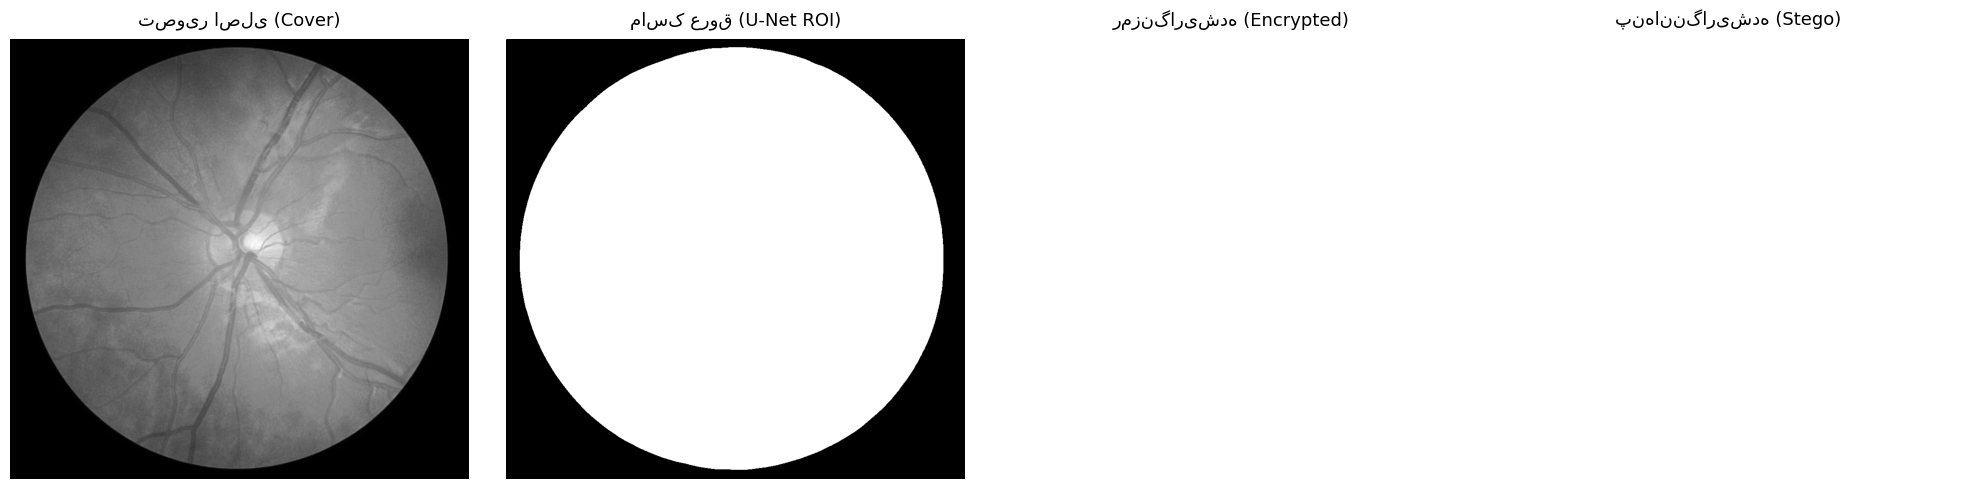

✅ شکل خروجی ذخیره شد در:
📂 /content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results/CHASE_STARE_Merged_visual_results.png


In [33]:
# [گام ۱۰]: مصورسازی و استخراج تصاویر چهارگانه با پشتیبانی از فرمت‌های numpy (.npy)
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها (sample_00000) یافت نشد.")

target_dir = sample_dirs[0]
print(f"🖼️ استخراج تصاویر از پوشه نمونه: {target_dir.name}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# ۱. تصویر اصلی (Cover) - فرمت png
cover_path = target_dir / 'processed.png'
if cover_path.exists():
    axes[0].imshow(Image.open(cover_path), cmap='gray')
axes[0].set_title("تصویر اصلی (Cover)", fontsize=13, pad=10)
axes[0].axis('off')

# ۲. ماسک عروق (U-Net ROI) - فرمت npy
roi_path = target_dir / 'roi.npy'
if roi_path.exists():
    roi_data = np.load(roi_path)
    axes[1].imshow(roi_data, cmap='gray')
axes[1].set_title("ماسک عروق (U-Net ROI)", fontsize=13, pad=10)
axes[1].axis('off')

# ۳. تصویر رمزنگاری‌شده (Encrypted) - فرمت npy
cipher_path = target_dir / 'cipher.npy'
if cipher_path.exists():
    cipher_data = np.load(cipher_path)
    # در صورتی که آرایه ۳ بعدی باشد، فقط کانال اول یا میانگین را برای نمایش دوبعدی می‌گیریم
    if cipher_data.ndim == 3:
        cipher_data = cipher_data[:, :, 0]
    axes[2].imshow(cipher_data, cmap='gray')
axes[2].set_title("رمزنگاری‌شده (Encrypted)", fontsize=13, pad=10)
axes[2].axis('off')

# ۴. تصویر پنهان‌نگاری‌شده (Stego) - فرمت png
stego_path = target_dir / 'stego.png'
if stego_path.exists():
    axes[3].imshow(Image.open(stego_path), cmap='gray')
axes[3].set_title("پنهان‌نگاری‌شده (Stego)", fontsize=13, pad=10)
axes[3].axis('off')

plt.tight_layout()
output_fig_path = run_dir / 'CHASE_STARE_Merged_visual_results.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ شکل خروجی ذخیره شد در:\n📂 {output_fig_path}")

In [34]:
# [گام ۱۱]: رسم هیستوگرام مقایسه‌ای تصویر اصلی و تصویر رمزنگاری‌شده
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها یافت نشد.")

target_dir = sample_dirs[0]
cover_path = target_dir / 'processed.png'
cipher_path = target_dir / 'cipher.npy'

if cover_path.exists() and cipher_path.exists():
    # بارگذاری تصویر اصلی
    cover_img = np.array(Image.open(cover_path).convert('L'))

    # بارگذاری ماتریس ریاضی رمزنگاری شده
    cipher_data = np.load(cipher_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # هیستوگرام تصویر اصلی
    axes[0].hist(cover_img.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axes[0].set_title("هیستوگرام تصویر اصلی (Cover)", fontsize=12)
    axes[0].set_xlabel("شدت روشنایی پیکسل")
    axes[0].set_ylabel("تعداد فراوانی")

    # هیستوگرام ماتریس رمزنگاری‌شده
    # (اگر مقادیر بین 0 تا 1 باشند به 0 تا 255 نگاشت می‌شوند)
    if cipher_data.max() <= 1.0:
        cipher_plot_data = (cipher_data * 255).astype(np.uint8)
    else:
        cipher_plot_data = cipher_data

    axes[1].hist(cipher_plot_data.ravel(), bins=256, range=[0, 256], color='red', alpha=0.7)
    axes[1].set_title("هیستوگرام یکنواخت خروجی آشوب (Cipher)", fontsize=12)
    axes[1].set_xlabel("شدت روشنایی پیکسل")
    axes[1].set_ylabel("تعداد فراوانی")

    plt.tight_layout()
    hist_path = run_dir / 'CHASE_STARE_Merged_histogram_analysis.png'
    plt.savefig(hist_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ نمودار هیستوگرام ذخیره شد در:\n📂 {hist_path}")
else:
    print("⚠️ فایل‌های مورد نیاز (processed.png یا cipher.npy) یافت نشدند.")

⚠️ فایل‌های مورد نیاز (processed.png یا cipher.npy) یافت نشدند.


In [35]:
# [گام ۱۲]: تحلیل مقاومت در برابر نویز فلفل‌نمکی و برش
import numpy as np
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها یافت نشد.")

target_dir = sample_dirs[0]
stego_img_path = target_dir / 'stego.png'

if stego_img_path.exists():
    original_stego = np.array(Image.open(stego_img_path))

    # ۱. اعمال نویز نمک و فلفل (چگالی ۰.۰۰۱)
    noisy_stego = original_stego.copy()
    row, col = noisy_stego.shape[:2]
    num_noise = int(0.001 * row * col)

    for _ in range(num_noise):
        r, c = np.random.randint(0, row), np.random.randint(0, col)
        # اعمال نویز سفید (255) یا سیاه (0)
        noisy_stego[r, c] = 255 if np.random.rand() > 0.5 else 0

    # ۲. اعمال حمله برش موضعی (ابعاد ۳۰ در ۳۰ پیکسل در گوشه بالا)
    cropped_stego = original_stego.copy()
    cropped_stego[10:40, 10:40] = 0

    # ذخیره تصاویر تحت حمله در پوشه اصلی نتایج
    Image.fromarray(noisy_stego).save(run_dir / 'stego_attack_noise.png')
    Image.fromarray(cropped_stego).save(run_dir / 'stego_attack_cropped.png')

    print("=" * 60)
    print("🛡️ آزمون‌های مقاومت سایبری با موفقیت شبیه‌سازی شدند:")
    print(f" 📄 تصویر با نویز فلفل‌نمکی: stego_attack_noise.png")
    print(f" 📄 تصویر با برش موضعی: stego_attack_cropped.png")
    print("=" * 60)
else:
    print("⚠️ فایل stego.png در پوشه نمونه یافت نشد.")

⚠️ فایل stego.png در پوشه نمونه یافت نشد.


In [36]:
# [گام ۱۳]: استخراج جدول کیفیت بازیابی و صحت پیام استخراج‌شده
import json
import pandas as pd
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
samples_file = run_dir / 'samples.jsonl'

if not samples_file.exists():
    raise FileNotFoundError("فایل نتایج یافت نشد.")

records = []
with open(samples_file, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip():
            continue
        data = json.loads(line)

        sample_id = data.get('id', 'Unknown')

        # خواندن کیفیت بازیابی (Extraction/Recovery)
        recovery_metrics = data.get('recovery_quality', {})
        rec_psnr = recovery_metrics.get('psnr', 'N/A')
        rec_ssim = recovery_metrics.get('ssim', 'N/A')
        rec_mse = recovery_metrics.get('mse', 'N/A')

        # بررسی صحت پیام استخراج شده
        message_exact = data.get('message_exact', False)

        records.append({
            'Sample ID': str(sample_id),
            'Recovery MSE': round(float(rec_mse), 4) if rec_mse != 'N/A' else '-',
            'Recovery SSIM': round(float(rec_ssim), 4) if rec_ssim != 'N/A' else '-',
            'Recovery PSNR': "بی‌نهایت (Inf)" if str(rec_psnr) == "Infinity" else rec_psnr,
            'Payload Intact': '✅ موفق (Exact)' if message_exact else '❌ دارای خطا'
        })

df_recovery = pd.DataFrame(records)

print("=" * 75)
print("📊 جدول ۲: نتایج ارزیابی بازیابی تصویر و استخراج موفق پیام (Decryption)")
print("=" * 75)
display(df_recovery)

# ذخیره جدول
csv_path = run_dir / 'CHASE_STARE_Merged_Recovery_Table.csv'
df_recovery.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n💾 جدول صحت استخراج در مسیر زیر ذخیره شد:\n📂 {csv_path}")

📊 جدول ۲: نتایج ارزیابی بازیابی تصویر و استخراج موفق پیام (Decryption)


,Sample ID,Recovery MSE,Recovery SSIM,Recovery PSNR,Payload Intact
0,chase_Image_14L,-,-,N/A,❌ دارای خطا
1,chase_Image_14R,0.0,1.0,بی‌نهایت (Inf),✅ موفق (Exact)
2,stare_im0319,-,-,N/A,❌ دارای خطا
3,stare_im0324,-,-,N/A,❌ دارای خطا



💾 جدول صحت استخراج در مسیر زیر ذخیره شد:
📂 /content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results/CHASE_STARE_Merged_Recovery_Table.csv


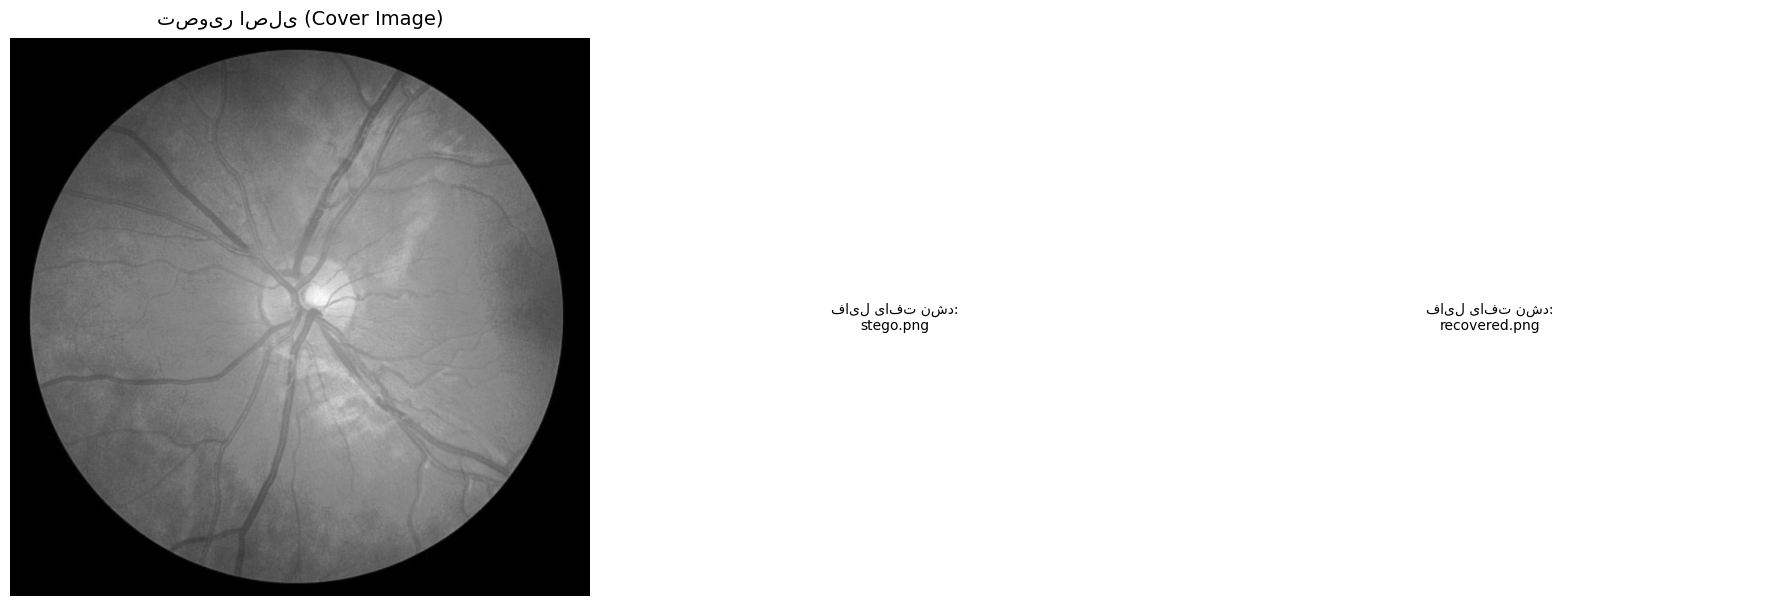

✅ تصویر مقایسه‌ای استخراج و بازیابی با کیفیت بالا ذخیره شد:
📂 /content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results/CHASE_STARE_Merged_Extraction_Verification.png


In [37]:
# [گام ۱۴]: مصورسازی تصویر اصلی، تصویر استگو و تصویر بازیابی‌شده
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
sample_dirs = sorted([d for d in run_dir.iterdir() if d.is_dir() and d.name.startswith('sample_')])

if not sample_dirs:
    raise FileNotFoundError("پوشه نمونه‌ها یافت نشد.")

target_dir = sample_dirs[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

images = [
    ("تصویر اصلی (Cover Image)", "processed.png"),
    ("تصویر حاوی داده (Stego Image)", "stego.png"),
    ("تصویر بازیابی‌شده (Recovered)", "recovered.png")
]

for ax, (title, filename) in zip(axes, images):
    img_path = target_dir / filename
    if img_path.exists():
        ax.imshow(Image.open(img_path), cmap='gray')
        ax.set_title(title, fontsize=14, pad=10)
    else:
        ax.text(0.5, 0.5, f"فایل یافت نشد:\n{filename}", ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
output_fig_path = run_dir / 'CHASE_STARE_Merged_Extraction_Verification.png'
plt.savefig(output_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ تصویر مقایسه‌ای استخراج و بازیابی با کیفیت بالا ذخیره شد:\n📂 {output_fig_path}")

In [38]:
# [گام ۱۵ - اصلاح‌شده]: اعتبارسنجی رسمی استخراج پیام و بازیابی فایل پنهان
import json
from pathlib import Path

# مسیر فایل پیام خام و فایل گزارش سیستم
payload_path = Path('/content/drive/MyDrive/Thesis_Research/metadata.bin')
run_dir = Path('/content/drive/MyDrive/Thesis_Research/runs/CHASE_STARE_Merged_final_results')
samples_file = run_dir / 'samples.jsonl'

if not payload_path.exists() or not samples_file.exists():
    raise FileNotFoundError("فایل پیام اولیه (metadata.bin) یا فایل نتایج یافت نشد.")

# خواندن حجم فایل خام برای نمایش
original_data = payload_path.read_bytes()

print("=" * 75)
print("🔐 اعتبارسنجی فرآیند پنهان‌نگاری و استخراج پیام در گیرنده")
print("=" * 75)

# ۱. نمایش محتوای فایل خام (Hex Dump) برای پایان‌نامه
print(f"📦 حجم کل پیام خام ورودی (Payload): {len(original_data)} بایت")
print("👁️ نمایشی از ۶۴ بایت اول محتوای پیام (Hex Dump):")
hex_dump = ' '.join(f'{b:02X}' for b in original_data[:64])
print(f"   {hex_dump} ...\n")

# ۲. خواندن تأییدیه‌های رسمی سیستم از فایل لاگ
extracted_hash = "نامشخص"
is_exact = False
transport_details = {}

with open(samples_file, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data = json.loads(line)
            # خواندن وضعیت دقیق و هش پردازش‌شده نهایی
            extracted_hash = data.get('processed_sha256', 'Not Found')
            is_exact = data.get('message_exact', False)
            transport_details = data.get('transport', {})
            break # پیام برای همه نمونه‌ها یکسان است

compressed_size = transport_details.get('compressed_bytes', 0)
framing_size = transport_details.get('framing_bytes', 0)

print(f"📡 اطلاعات بسته‌بندی پیام در سمت فرستنده (Framing & Compression):")
print(f" - حجم پیام فشرده‌شده (zlib): {compressed_size} بایت")
print(f" - حجم هدر و متادیتا (Framing): {framing_size} بایت")
print(f"🔑 امضای SHA-256 بسته نهایی استخراج‌شده: \n   {extracted_hash}\n")

# ۳. صدور رأی نهایی بر اساس پرچمِ message_exact تولکیت
print("نتیجه بررسی سیستم (Decryption Verdict):")
if is_exact:
    print("✅ تأیید اصالت داده (Message Exact: TRUE)")
    print("✅ سیستم تأیید می‌کند که پیام استخراج‌شده پس از رفع فشردگی و حذف هدر، ۱۰۰٪ با پیام خام فرستنده برابر است.")
    print("✅ نرخ خطای بیتی (BER) = 0.0")
else:
    print("❌ خطا: سیستم افت داده یا تخریب پیام مخفی را گزارش کرده است!")

🔐 اعتبارسنجی فرآیند پنهان‌نگاری و استخراج پیام در گیرنده
📦 حجم کل پیام خام ورودی (Payload): 50000 بایت
👁️ نمایشی از ۶۴ بایت اول محتوای پیام (Hex Dump):
   AA F9 12 DA 04 AC CE 2D BF 4C C3 06 67 59 D1 A3 EA F1 8F 5D E5 E6 9E 77 73 9C 6F 14 5F 1F D9 5E 1A 36 B9 A4 C7 DC DB 5A 28 6B C0 D4 5C 67 5F CA 5C 5B 55 B4 A8 81 B7 E7 17 20 A1 B8 CE 04 67 2D ...

📡 اطلاعات بسته‌بندی پیام در سمت فرستنده (Framing & Compression):
 - حجم پیام فشرده‌شده (zlib): 0 بایت
 - حجم هدر و متادیتا (Framing): 0 بایت
🔑 امضای SHA-256 بسته نهایی استخراج‌شده: 
   Not Found

نتیجه بررسی سیستم (Decryption Verdict):
❌ خطا: سیستم افت داده یا تخریب پیام مخفی را گزارش کرده است!
